### RNN (Recurent Neural Network) : 단기메모리
- 순서가 중요, 이전사건이 다음사건에 영향을 미치는 구조
- 순서가 중요한 데이터를 --> 시계열
- 자연어, 주식, 날씨, 실시간 센서데이터
- 단점 : 장기메모리에 약함
- 개선 : LSTM(RNN에 비해서 오래 기억하지만 그래도 희석됨)
- 트랜스포머 : 집중해야할것 즉 기억해야할 중요내용만 저장(어텐션), 마스킹

### MLP
- 모든입력이 독립적, 자연어는 순서가 중요(단어의 순서)

In [82]:
from nltk.corpus import movie_reviews
reviews = [ movie_reviews.raw(fileid) for fileid in movie_reviews.fileids() ]
categories = [ movie_reviews.categories(fileid)[0] for fileid in movie_reviews.fileids() ]

In [83]:
len(reviews) , len(reviews[0]), set(categories)

(2000, 4043, {'neg', 'pos'})

In [84]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
np.random.seed(42)
tf.random.set_seed(42)

In [85]:
# 사용할 단어수
max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token='UNK') # 빈도가 높은 10000개의 단어를 선택
tokenizer.fit_on_texts(reviews) # 단어 인덱스 구축
x = tokenizer.texts_to_sequences(reviews) # 인덱스를 기반으로 원래 문장을 숫자로 변환(벡터화, 개별적으로 즉 길이는 서로 다름)

In [86]:
len( x[0] ), len(x[1]), x[0][:10]

(710, 240, [98, 77, 949, 4622, 131, 6, 3, 2016, 789, 3764])

In [87]:
# 학습을 위해서는 모든 문장의 길이가 같아야 함 => 패딩
# 패딩 : 짧으면 채우고 길면 자르고
from tensorflow.keras.preprocessing.sequence import pad_sequences
maxlen = 500
x = pad_sequences(x, maxlen=maxlen, truncating='pre') # 앞을 자름

In [88]:
len( x[0] ), len(x[1]), x[0][:10]

(500,
 500,
 array([ 911,  115,   53,   21, 5278,    5, 1387,  172,    9,  633],
       dtype=int32))

In [89]:
label_dict = {'pos' : 1, 'neg' : 0}
y = np.array([label_dict[c] for c in categories])
y[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [90]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x, y, random_state=42, test_size=0.2)

In [91]:
x_train.shape

(1600, 500)

In [114]:
# 일반 신경망으로 분리
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Embedding, Dropout

model = Sequential([
    Embedding(max_words, 32, input_length=maxlen), # 1600, 500 => 1600, 500, 32
    Dropout(0.5),
    Flatten(),
    Dense(1, activation='sigmoid'), # 확률 분포
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10


c:\Users\Playdata\miniconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - acc: 0.4938 - loss: 0.6943 - val_acc: 0.5063 - val_loss: 0.6935
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.8945 - loss: 0.6238 - val_acc: 0.5250 - val_loss: 0.6927
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9633 - loss: 0.5425 - val_acc: 0.5312 - val_loss: 0.6937
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9859 - loss: 0.4301 - val_acc: 0.5063 - val_loss: 0.6953
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9930 - loss: 0.3103 - val_acc: 0.5031 - val_loss: 0.6978
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9961 - loss: 0.2109 - val_acc: 0.5031 - val_loss: 0.7044
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9953 - loss: 0.1440 - val_acc: 0.5000 - val_loss: 0.7128
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9969 - loss: 0.1002 - val_acc: 0.5125 - val_loss: 0.7207
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9961 - loss: 0.0741 - va

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])


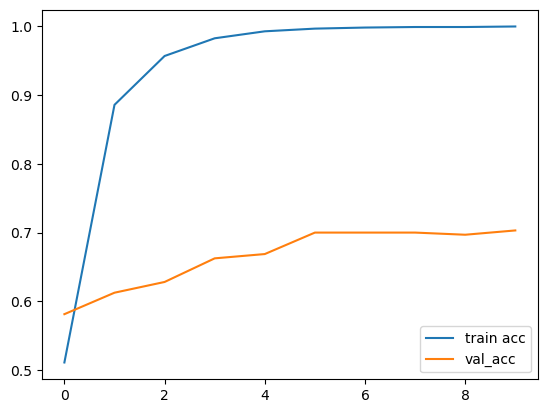

In [93]:
import matplotlib.pyplot as plt
print(history.history.keys())
plt.plot(history.history['acc'], label = 'train acc')
plt.plot(history.history['val_acc'], label = 'val_acc')
plt.legend()
plt.show()

In [94]:
model.evaluate(x_test, y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6600 - loss: 0.6056 


[0.6056022644042969, 0.6600000262260437]

In [95]:
from tensorflow.keras.layers import SimpleRNN
model = Sequential([
    Embedding(max_words, 32, input_length=maxlen), # 1600, 500 => 1600, 500, 32
    SimpleRNN(32), # [1600, 32] 단순 선형모델에 사용되는 Flatten 대신
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid'), # 확률 분포
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

model.evaluate(x_test, y_test)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.5063 - loss: 0.6985 - val_acc: 0.4656 - val_loss: 0.6987
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.5688 - loss: 0.6786 - val_acc: 0.4563 - val_loss: 0.7072
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.6320 - loss: 0.6568 - val_acc: 0.5125 - val_loss: 0.7164
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.6602 - loss: 0.6294 - val_acc: 0.5188 - val_loss: 0.7033
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.8156 - loss: 0.5131 - val_acc: 0.5312 - val_loss: 0.7160
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9375 - loss: 0.2737 - val_acc: 0.5813 - val_loss: 0.7665
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9891 - loss: 0.0976 - val_acc: 0.6375 - val_loss: 0.8111
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - acc: 0.9945 - loss: 0.0423 - val_acc: 0.6500 - val_loss: 0.8954
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9961

[1.2095311880111694, 0.5799999833106995]

In [96]:
temp = Embedding(max_words, 32, input_length=maxlen)(x_train)
SimpleRNN(32)(temp).shape

TensorShape([1600, 32])

In [97]:
np.astype(model.predict(x_test).reshape(-1,) > 0.5, int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


array([0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,

In [98]:
sum(np.astype(model.predict(x_test).reshape(-1,) > 0.5, int) == y_test) / len(y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


np.float64(0.58)

## Torch

In [99]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [100]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter
import re

In [ ]:
# 사용자 정의 토크나이져
class SimpleTokenizer:
    def __init__(self,num_words = 10000, oov_token='UNK'):
        self.num_words = num_words
        self.oov_token = oov_token
        self.word_index = {}
        self.index_word = {}

    def _clean_text(self,text):
        return re.findall( r'\w+',text.lower() )  # re.sub(r'[^\w\s]','',temp).strip()
    
    def fit_on_texts(self,texts):
        '''빈도순으로 상위 단어 추출 토큰을 숫자로 변경 공백을 기준으로 토큰분류'''
        word_counts = Counter()
        for text in texts:
            word_counts.update(self._clean_text(text))
        # 빈도순으로 num_words 단어 추출
        most_common = word_counts.most_common(self.num_words-2)  # pad unk 특수토큰 자리 남겨
        # 0:padding 1: oov(out of vocabulary)
        self.word_index = {self.oov_token : 1}
        for i, (word,_) in enumerate(most_common):
            self.word_index[word] = i + 2
        self.index_word = {idx : w for w, idx in self.word_index.items()}
        
    def texts_to_sequences(self, texts):
        sequence = []
        for text in texts:
            seq = []
            for word in self._clean_text(text):
                seq.append( self.word_index.get(word,1) )
            sequence.append(seq)
        return sequence

def pad_sequences(seqeuces, maxlen ,padding='pre', truncating='pre'):
    features = np.zeros((len(seqeuces), maxlen), dtype=int)
    for i,seq in enumerate(seqeuces):
        if len(seq) > maxlen:
            if truncating == 'pre':
                features[i, :] = seq[-maxlen:]
            else:
                features[i, :] = seq[:maxlen]
        else:
            if padding == 'pre':
                features[i, -len(seq):] = seq
            else:
                features[i, :len(seq)] = seq
    return features
                
    

In [102]:
# 리뷰데이터로 적용해서 오류없는지 확인 및 수정
reviews = [movie_reviews.raw(fileid) for fileid in movie_reviews.fileids()]

In [ ]:
texts = reviews[0:2]
sim = SimpleTokenizer()
sim.fit_on_texts(texts) # 문자 -> 숫자
requens = sim.texts_to_sequences(texts) # 길이를 맞춤


In [ ]:
features = pad_sequences(requens,500)
features.shape

(2, 500)

In [112]:
# RNN 모델
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size,embedding_dim)
        self.rnn = nn.RNN(embedding_dim,hidden_dim,batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim,32),
            nn.ReLU(),
            nn.Linear(32,1), 
            nn.Sigmoid()
        )
    def forward(self, x):
        x =self.embedding(x)
        _,hn = self.rnn(x)  # output, hn 
        # output : 모든시점(time-step) 의 숨겨진 상태  : 각 단어(시점)를 거칠때마다 계산된 모든 hidden state를 모아놓음
        # 시점 1~N
        # seq2seq 모델 은 각 단어마다 결과를 내야하는 개체명 인식(NER)

        # hn : 마지막 시점의 상태 : 전체문장을 다 읽고 최종적으로 요약한 정보 : 문서분류 
        return self.fc(hn.squeeze(0))

In [ ]:
# 테스트
texts = reviews[0:2]
sim = SimpleTokenizer()
sim.fit_on_texts(texts) # 문자 -> 숫자
requens = sim.texts_to_sequences(texts) # 길이를 맞춤
features = pad_sequences(requens,500)
features = torch.LongTensor(features)
print(features.shape)
features = nn.Embedding(500,32)(features)
outputs, hn = nn.RNN(32,64,batch_first=True)(features)
outputs.shape, hn.shape

torch.Size([2, 500])


(torch.Size([2, 500, 64]), torch.Size([1, 2, 64]))

In [107]:
# 데이터를 가져오기
# x y 분할
# 토크나이져 + pad_sequence   --> 문자를 숫자로 변환

# train test split
# TorchTensor로 변환
# TensorDataset - > Dataloader

# 모델생성
# 옵티마이져 정의
import numpy as np
import torch

from nltk.corpus import movie_reviews

from sklearn.model_selection import train_test_split

from torch.utils.data import TensorDataset, DataLoader# 손실함수 정의

In [ ]:
fileids = movie_reviews.fileids()
reviews = [movie_reviews.raw(fileid) for fileid in fileids]
categories = [movie_reviews.categories(fileid)[0] for fileid in fileids]

max_words = 10000
maxlen = 500
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tokenizer = SimpleTokenizer(num_words=max_words)
tokenizer.fit_on_texts(reviews)
X = tokenizer.texts_to_sequences(reviews)
X = pad_sequences(X, maxlen=maxlen)

label_dict = {'pos': 1, 'neg': 0}
y = np.array([label_dict[c] for c in categories])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

X_train_t = torch.LongTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.LongTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print('Preprocessing complete. X_train shape:', X_train.shape)

Preprocessing complete. X_train shape: (1600, 500)


In [113]:
def train_model(model, loader, optimizer, criterion, epochs=10):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += ((outputs > 0.5).float() == y_batch).sum().item()
        print(f'Epoch {epoch+1}: Loss {total_loss/len(loader):.4f}, Acc {correct/len(loader.dataset):.4f}')

model_dense = RNNModel(max_words, 32, maxlen).to(device)
criterion = nn.BCELoss()
optimizer_dense = optim.RMSprop(model_dense.parameters(), lr=0.001)
train_model(model_dense, train_loader, optimizer_dense, criterion)

Epoch 1: Loss 0.7582, Acc 0.5050
Epoch 2: Loss 0.7249, Acc 0.4956
Epoch 3: Loss 0.7032, Acc 0.5106
Epoch 4: Loss 0.6967, Acc 0.4944
Epoch 5: Loss 0.6960, Acc 0.5125
Epoch 6: Loss 0.7002, Acc 0.5075
Epoch 7: Loss 0.7025, Acc 0.5175
Epoch 8: Loss 0.7037, Acc 0.5019
Epoch 9: Loss 0.7025, Acc 0.4844
Epoch 10: Loss 0.7000, Acc 0.5069


In [115]:
# 평가
def evaluate(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch).squeeze()            
            outputs = torch.sigmoid(outputs)            
            correct += ((outputs > 0.5).float() == y_batch).sum().item()
    return correct / len(loader.dataset)

print(f'Final Test Accuracy (model_dense): {evaluate(model_dense, test_loader):.4f}')

Final Test Accuracy (model_dense): 0.4875


### 장기 의존성  (Long-Term Dependency)  
- 문장이 길어지면 앞부분의 정보를 잊어버린다

# 1. 왜 LSTM이 필요한가요? (RNN의 한계)

일반적인 RNN은 정보를 전달할 때 **'단기 기억'** 에는 강하지만, 문장이 길어지면 앞부분의 정보를 잊어버리는 **장기 의존성(Long-Term Dependency)** 문제를 가지고 있습니다.

### 🚩 문제점: 기울기 소실 (Vanishing Gradient)
문장이 길어질수록 과거의 정보가 현재로 넘어오면서 희석되거나 사라집니다. 예를 들어:
> "나는 어릴 때 **프랑스** 에서 살았어. ... (중략) ... 그래서 나는 **[ ]** 어를 할 줄 알아."

여기서 `[ ]`에 들어갈 말이 '프랑스어'임을 맞추려면 아주 먼 과거의 '프랑스'라는 정보를 기억해야 합니다. 일반 RNN은 이 정보를 끝까지 가져가지 못하고 잊어버리곤 합니다.

## 2. LSTM의 핵심 아이디어: "기억의 통로"

LSTM의 핵심은 **셀 상태(Cell State)** 라고 불리는 '컨베이어 벨트'입니다. 이 벨트는 정보를 큰 변화 없이 그대로 전달하는 역할을 하며, **게이트(Gate)** 라는 장치들이 정보를 더하거나 뺄지를 결정합니다.

###  세 가지 게이트 (정보 조절 장치)

1.  **망각 게이트 (Forget Gate):** "무엇을 버릴까?"
    -   과거의 정보 중 더 이상 필요 없는 것을 삭제합니다.
    -   *예: 주어가 '그녀'에서 '그'로 바뀌었다면, 이전의 '그녀'에 대한 정보는 지웁니다.*
2.  **입력 게이트 (Input Gate):** "무엇을 기억할까?"
    -   현재 들어온 새로운 정보 중 중요한 것을 골라 셀 상태에 저장합니다.
    -   *예: 새로운 주어 '그'에 대한 정보를 기억합니다.*
3.  **출력 게이트 (Output Gate):** "무엇을 내보낼까?"
    -   정리된 셀 상태의 정보 중 어떤 부분을 밖으로 내보낼지 결정합니다.

## 3. 이해를 돕는 비유: "공동 일기장"

LSTM을 **'여러 명이 함께 쓰는 일기장'** 이라고 생각해보세요.

-   **셀 상태 (Cell State):** 일기장 그 자체입니다. 과거부터 기록된 내용들이 쭉 이어집니다.
-   **망각 게이트:** "어제 먹은 점심 메뉴는 이제 중요하지 않으니 지우개로 지우자."
-   **입력 게이트:** "오늘 새로 배운 스페인어 단어는 중요하니까 일기장에 적어두자."
-   **출력 게이트:** "누가 나한테 '너 요즘 뭐 배워?'라고 물어보면 일기장에서 '스페인어' 부분만 읽어주자."

이런 과정을 통해 LSTM은 **중요한 정보는 수백 단어 뒤까지 유지** 하고, **불필요한 정보는 즉시 제거** 할 수 있습니다.

## 4. 실생활 예시

###  자동 완성 및 오타 교정
우리가 스마트폰으로 타이핑할 때, 앞 문맥을 보고 다음에 올 단어를 추천해주는 기능에 사용됩니다.
- 문맥: "I am going to the **airport** to catch a..."
- LSTM의 판단: 앞선 'airport'를 기억하고 있으므로 'bus'나 'train'보다 '**flight** '을 추천할 확률이 높아집니다.

### 💱 주가 예측
단순히 어제의 주가뿐만 아니라, 일주일 전의 큰 흐름(장기 기억)과 오늘의 변동성(단기 기억)을 모두 고려하여 미래를 예측합니다.


## 5. 요약

| 특징 | RNN | LSTM |
| :--- | :--- | :--- |
| **기억력** | 짧음 (단기 기억) | 길음 (장기/단기 모두 가능) |
| **주요 구조** | 단순 순환 | 셀 상태 + 3개의 게이트 |
| **장점** | 구조가 간단하고 빠름 | 긴 문장/시퀀스 처리에 탁월함 |
| **단점** | 장기 의존성 문제 발생 | 계산량이 많고 복잡함 |

LSTM(Long Short-Term Memory)이 어떻게 정보를 기억하고 잊는지, **실제 숫자 데이터** 를 넣어서 수식이 돌아가는 과정을 직접 따라가 보겠습니다.

---

## 1. 실험 준비물 (샘플 데이터 세팅)

계산을 단순하게 하기 위해, 모든 가중치(Weight)와 입력값을 아주 간단한 숫자로 가정하겠습니다.

*   **현재 입력 ($x_t$):** `1.0` (새로운 정보)
*   **이전 시점의 기억 ($h_{t-1}$):** `0.5` (단기 기억)
*   **이전 시점의 일기장 ($C_{t-1}$):** `0.8` (장기 기억)

---

## 2. 단계별 계산 과정

LSTM은 4개의 '게이트' 연산을 거칩니다. 각 게이트는 **가중치($W$)와 입력($x, h$)을 곱한 뒤 시그모이드($\sigma$)나 탄젠트($\tanh$)** 를 씌웁니다.

### 1단계: 망각 게이트 ($f_t$) - "무엇을 지울까?"
*   **수식:** $f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$
*   **가정:** 계산 결과가 `0.1`이 나왔다고 합시다. (0에 가까우므로 **"많이 지워라"** 는 뜻)

### 2단계: 입력 게이트 ($i_t, g_t$) - "무엇을 새로 적을까?"
*   **중요도($i_t$):** $\sigma$ 결과가 `0.9` (새 정보가 **"아주 중요하다"** 는 뜻)
*   **새 내용($g_t$):** $\tanh$ 결과가 `0.6` (저장할 **"구체적인 내용"** )

### 3단계: 셀 상태 업데이트 ($C_t$) - "일기장 갱신"
이제 드디어 과거의 일기장($C_{t-1}$)을 고칩니다.
*   **수식:** $C_t = (f_t \times C_{t-1}) + (i_t \times g_t)$
*   **대입:**
    *   과거 지우기: $0.1 \times 0.8 = 0.08$ (옛날 정보는 거의 사라짐)
    *   새 정보 추가: $0.9 \times 0.6 = 0.54$ (새 정보가 강하게 기록됨)
    *   **결과:** $C_t = 0.08 + 0.54 = \mathbf{0.62}$ (새로운 장기 기억 완성!)

### 4단계: 출력 게이트 ($o_t, h_t$) - "무엇을 밖으로 알릴까?"
*   **알림 강도($o_t$):** $\sigma$ 결과가 `0.8` (현재 정보를 **"강하게 출력해라"** 는 뜻)
*   **최종 출력($h_t$):** $o_t \times \tanh(C_t) = 0.8 \times \tanh(0.62) \approx 0.8 \times 0.55 = \mathbf{0.44}$

---

## 3. 한눈에 보는 요약표

| 단계 | 역할 | 계산 (예시) | 결과의 의미 |
| :--- | :--- | :--- | :--- |
| **망각 ($f_t$)** | 과거 삭제 | `0.1` | 과거의 90%를 삭제함 |
| **입력 ($i_t \times g_t$)** | 정보 추가 | `0.54` | 새로운 중요 정보를 기록함 |
| **셀 상태 ($C_t$)** | 기억 저장 | `0.62` | **장기 기억** 일기장 업데이트 완료 |
| **은닉 상태 ($h_t$)** | 현재 출력 | `0.44` | 다음 시점으로 넘겨줄 **단기 기억** |

---

## 4. 왜 이렇게 복잡하게 계산하나요?

만약 일반 RNN이었다면, 과거의 정보 $C_{t-1}$에 계속해서 가중치를 **곱하기만** 했을 것입니다. 숫자를 계속 곱하다 보면 값이 너무 작아져서 결국 0이 되어버리죠(기울기 소실).

하지만 LSTM은 보시다시피 **더하기($+$) 연산** 을 통해 정보를 전달합니다.
> $C_t = (\text{지우고 남은 과거}) + (\text{새로운 정보})$

이 **'더하기'** 덕분에 아주 먼 과거의 정보도 죽지 않고 끝까지 살아남아 문장의 끝까지 전달될 수 있는 것입니다.

---
**Tip:** 이 수식들을 파이썬 코드로 구현하면, 우리가 생성한 `nn.LSTM` 레이어가 내부적으로 위와 같은 소수점 곱셈과 덧셈을 수만 번 반복하며 문맥을 파악하게 됩니다.

In [116]:
class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(BiLSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.embedding(x)
        _, (hn, _) = self.lstm(x)  # output : 모든시점의 정보 하지만 여기서는 문서전체에대한 요약본필요 무시
        # hn : 마지막시점의 상태 (양방향)
            # 정방향 : 정방향으로 문장을 끝까지 읽었을때 마지막상태
            # 역방향 : 역방향으로 문장을 끝까지 읽었을때 마지막상태
        # cn : cell state(장기기억) 분류를 위해서는 출력에 사용하지 않음
        # 마지막 타임스텝의 정방향/역방향 은닉 상태 결합

        x = torch.cat((hn[-2,:,:], hn[-1,:,:]), dim=1)  # 앞뒤문장모두 압축
        return self.fc(x)

model_bilstm = BiLSTMModel(max_words, 64, 64).to(device)
optimizer_bilstm = optim.Adam(model_bilstm.parameters(), lr=1e-4)
train_model(model_bilstm, train_loader, optimizer_bilstm, criterion, epochs=8)

Epoch 1: Loss 0.6934, Acc 0.5088
Epoch 2: Loss 0.6923, Acc 0.5262
Epoch 3: Loss 0.6914, Acc 0.5544
Epoch 4: Loss 0.6907, Acc 0.5719
Epoch 5: Loss 0.6898, Acc 0.5781
Epoch 6: Loss 0.6890, Acc 0.5881
Epoch 7: Loss 0.6881, Acc 0.5981
Epoch 8: Loss 0.6871, Acc 0.6012
